# EDA de Publicidad Digital

En este notebook analizamos cómo cambian los resultados por `Target_Audience`, `Campaign_Goal` y `Channel_Used`, con foco en `ROI`, `Conversion_Rate` y `Acquisition_Cost`.


In [1]:
from pathlib import Path
import sys

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from src.data.carga_datos import cargar_dataset
from src.data.limpieza import limpiar_dataset_publicidad
from src.data.features import crear_contexto, agregar_metricas_por_contexto_y_canal
from src.visualizacion.graficos import grafico_roi_por_canal, grafico_heatmap_roi

sns.set_theme(style='whitegrid')


In [2]:
df = cargar_dataset(ROOT / 'social_media_ads_filtered.csv')
df = limpiar_dataset_publicidad(df)
df = crear_contexto(df)
tabla_agregada = agregar_metricas_por_contexto_y_canal(df)

print('Filas:', len(df))
print('Canales:', sorted(df['Channel_Used'].unique()))
print('Audiencias:', sorted(df['Target_Audience'].unique()))
print('Objetivos:', sorted(df['Campaign_Goal'].unique()))


Filas: 4052
Canales: ['Facebook', 'Instagram', 'Pinterest', 'Twitter']
Audiencias: ['All Ages', 'Men 18-24', 'Men 25-34', 'Men 35-44', 'Men 45-60', 'Women 18-24', 'Women 25-34', 'Women 35-44', 'Women 45-60']
Objetivos: ['Brand Awareness', 'Increase Sales', 'Market Expansion', 'Product Launch']


In [3]:
df[['ROI', 'Conversion_Rate', 'Acquisition_Cost']].describe().T


,count,mean,std,min,25%,50%,75%,max
ROI,4052.0,3.201927,2.453677,0.00,0.977301,2.710,5.2700,8.00
Conversion_Rate,4052.0,0.081266,0.040707,0.01,0.050000,0.080,0.1200,0.15
Acquisition_Cost,4052.0,7728.181249,4265.627046,500.00,4129.907500,7629.495,11394.4675,15000.00


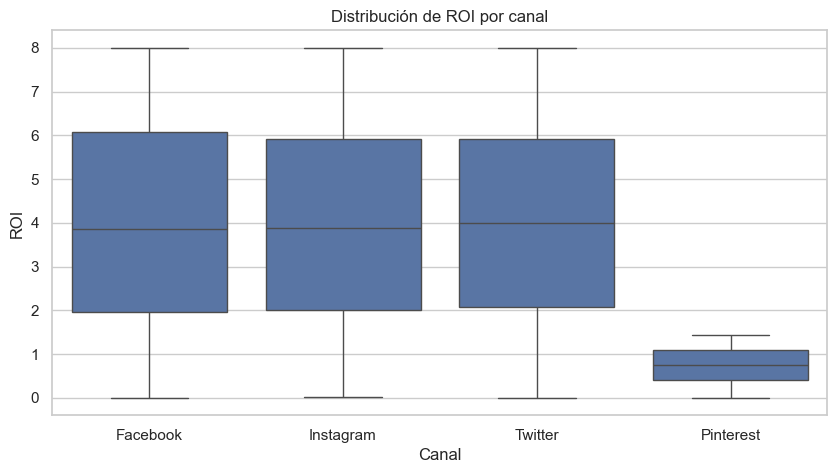

In [4]:
grafico_roi_por_canal(df)
plt.show()


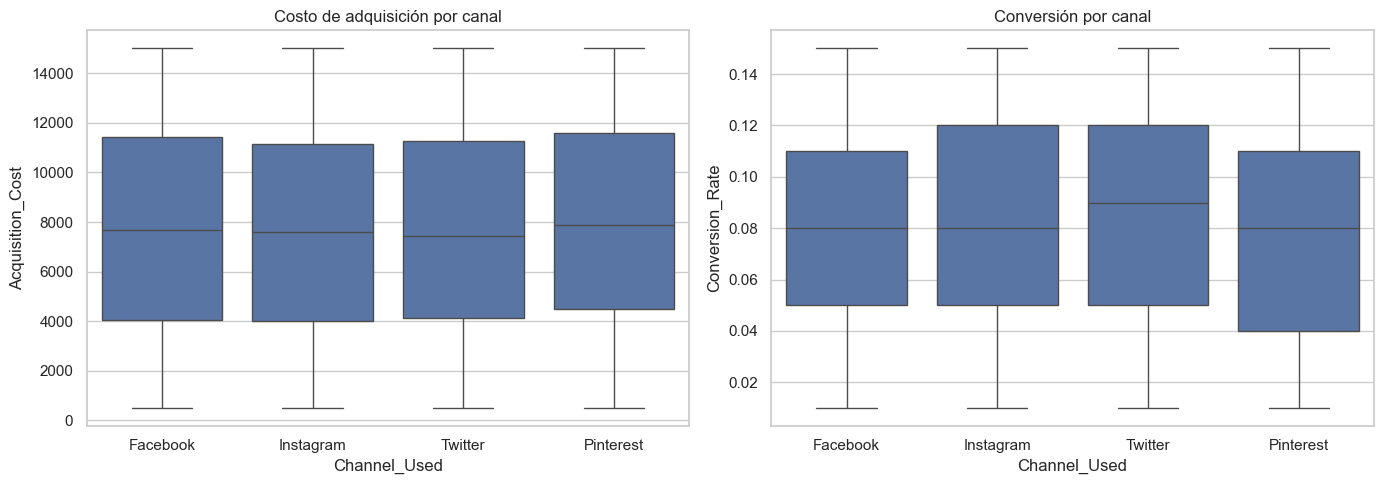

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(data=df, x='Channel_Used', y='Acquisition_Cost', ax=axes[0])
axes[0].set_title('Costo de adquisición por canal')
sns.boxplot(data=df, x='Channel_Used', y='Conversion_Rate', ax=axes[1])
axes[1].set_title('Conversión por canal')
plt.tight_layout()
plt.show()


In [6]:
mejores_contextos = (
    tabla_agregada
    .sort_values(['Contexto', 'roi_promedio', 'conversion_promedio'], ascending=[True, False, False])
    .drop_duplicates('Contexto')
    [['Target_Audience', 'Campaign_Goal', 'Channel_Used', 'roi_promedio', 'conversion_promedio', 'costo_promedio', 'n_observaciones']]
)

mejores_contextos.head(15)


,Target_Audience,Campaign_Goal,Channel_Used,roi_promedio,conversion_promedio,costo_promedio,n_observaciones
0,All Ages,Brand Awareness,Twitter,4.288095,0.070476,7570.991429,21
4,All Ages,Increase Sales,Twitter,4.176957,0.081304,6877.010000,23
8,All Ages,Market Expansion,Facebook,4.598125,0.083750,7575.532187,32
12,All Ages,Product Launch,Instagram,4.495385,0.081923,6354.018462,26
16,Men 18-24,Brand Awareness,Facebook,4.187500,0.083929,7079.548214,28
20,Men 18-24,Increase Sales,Instagram,4.221034,0.084138,7205.264138,29
24,Men 18-24,Market Expansion,Twitter,4.058000,0.083600,9489.632800,25
28,Men 18-24,Product Launch,Instagram,4.585789,0.083158,5266.302632,19
32,Men 25-34,Brand Awareness,Facebook,4.529000,0.073667,8222.873333,30
36,Men 25-34,Increase Sales,Instagram,4.347586,0.076897,7116.706207,29


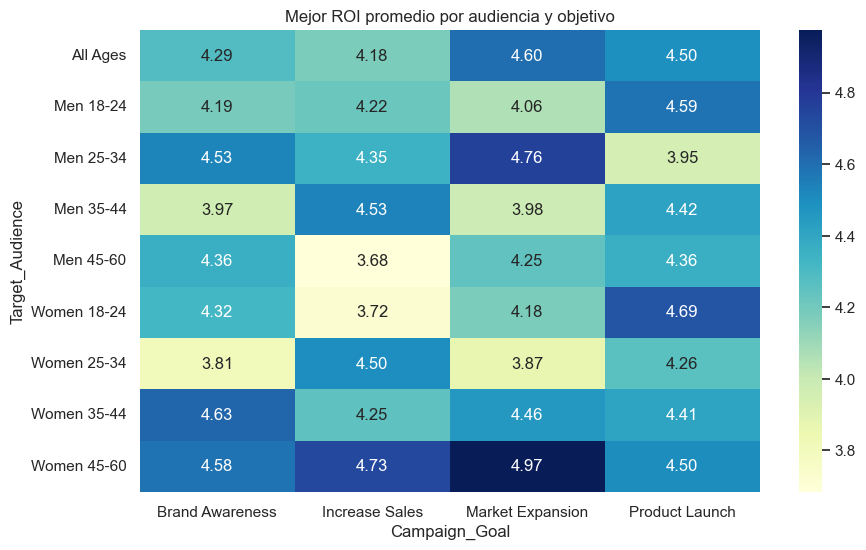

In [7]:
grafico_heatmap_roi(tabla_agregada)
plt.show()


## Gráficos adicionales de comparación

En esta parte agrego algunas vistas mas aterrizadas al problema de negocio, para entender mejor que canal conviene segun la audiencia, la campaña y la combinacion de ambas.


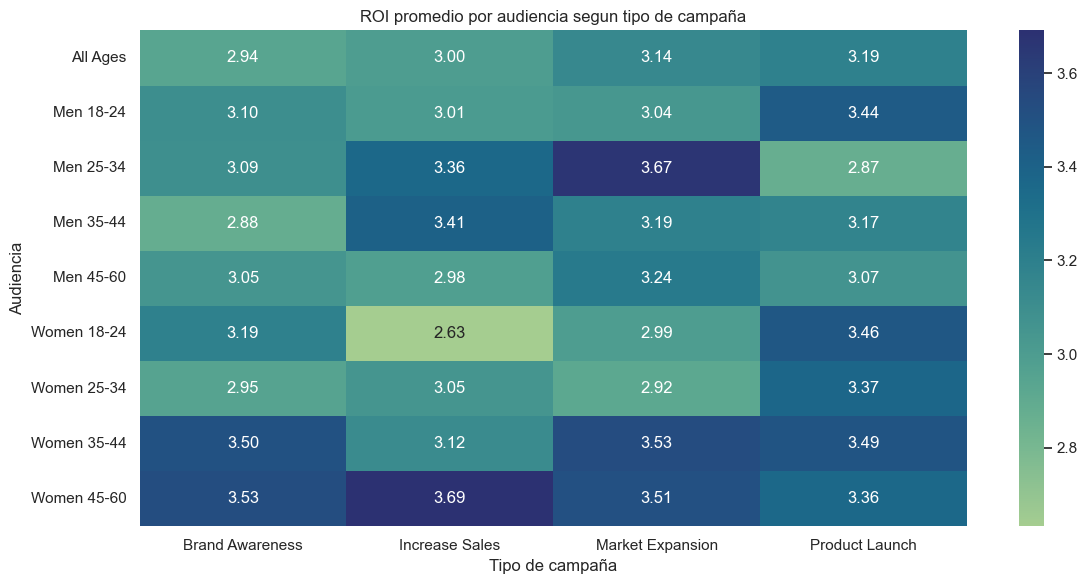

In [8]:
roi_audiencia_campania = (
    df.groupby(['Target_Audience', 'Campaign_Goal'], as_index=False)
    .agg(roi_promedio=('ROI', 'mean'))
)

tabla_roi_audiencia_campania = roi_audiencia_campania.pivot(
    index='Target_Audience',
    columns='Campaign_Goal',
    values='roi_promedio'
)

plt.figure(figsize=(12, 6))
sns.heatmap(tabla_roi_audiencia_campania, annot=True, fmt='.2f', cmap='crest')
plt.title('ROI promedio por audiencia segun tipo de campaña')
plt.xlabel('Tipo de campaña')
plt.ylabel('Audiencia')
plt.tight_layout()
plt.show()


En general para las mujeres el mejor ROI se presenta en campañas del tipo Product Launch, sin embargo par alas mujeres de 45 a 60 se tiene un ROI superior en todas las categorías de campañas

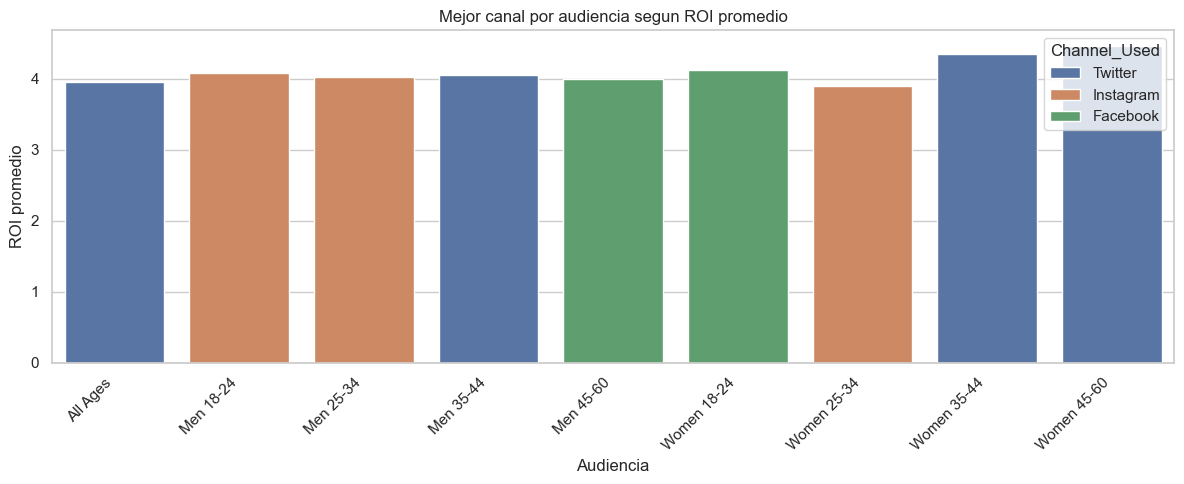

,Target_Audience,Channel_Used,roi_promedio,conversion_promedio,costo_promedio
3,All Ages,Twitter,3.950309,0.076392,7244.365464
5,Men 18-24,Instagram,4.082617,0.081028,7173.693178
9,Men 25-34,Instagram,4.022523,0.082804,7051.914393
15,Men 35-44,Twitter,4.057396,0.091667,7386.655417
16,Men 45-60,Facebook,3.991652,0.081304,8237.002696
20,Women 18-24,Facebook,4.123535,0.080404,7135.908485
25,Women 25-34,Instagram,3.893684,0.085263,8444.645088
31,Women 35-44,Twitter,4.352477,0.082477,7243.078349
35,Women 45-60,Twitter,4.459928,0.082899,7931.686812


In [11]:
mejor_canal_por_audiencia = (
    df.groupby(['Target_Audience', 'Channel_Used'], as_index=False)
    .agg(
        roi_promedio=('ROI', 'mean'),
        conversion_promedio=('Conversion_Rate', 'mean'),
        costo_promedio=('Acquisition_Cost', 'mean')
    )
    .sort_values(['Target_Audience', 'roi_promedio', 'conversion_promedio'], ascending=[True, False, False])
    .drop_duplicates('Target_Audience')
)

plt.figure(figsize=(12, 5))
sns.barplot(data=mejor_canal_por_audiencia, x='Target_Audience', y='roi_promedio', hue='Channel_Used')
plt.title('Mejor canal por audiencia segun ROI promedio')
plt.xlabel('Audiencia')
plt.ylabel('ROI promedio')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

mejor_canal_por_audiencia


Podemos apreciar que los hombres de 18 a 34 años prefieren Instagram, y este ha sido el canal que ha tenido mejor Retorno en la inversión, lo que significa que por el costo de adquisición han logrado mayores conversiones a ventas. Facebook es fuerte en hombres mayores de 45 y en mujeres jóvenes. En general los grupos tienen un sentimiento positivo hacia Twitter.

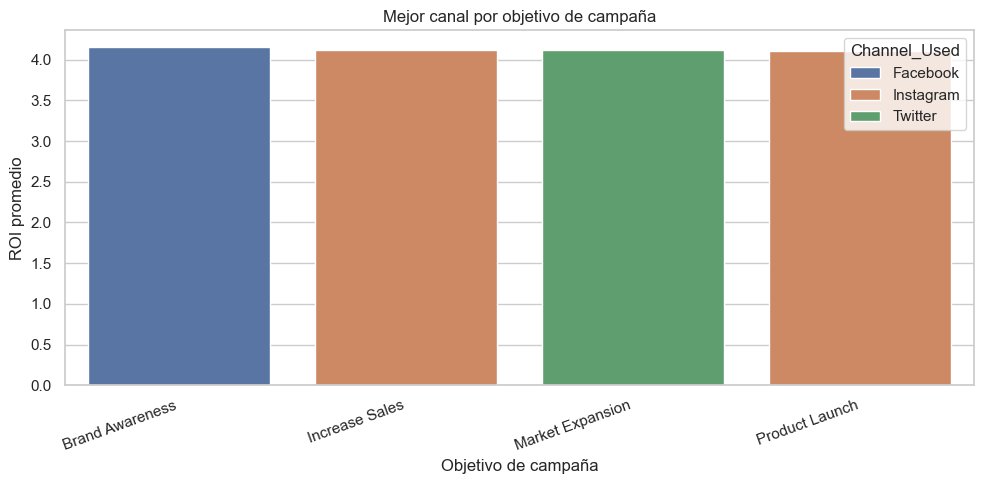

,Campaign_Goal,Channel_Used,roi_promedio,conversion_promedio,costo_promedio
0,Brand Awareness,Facebook,4.151468,0.079881,7795.843056
5,Increase Sales,Instagram,4.116083,0.079355,7199.142903
11,Market Expansion,Twitter,4.120954,0.083402,8110.654315
13,Product Launch,Instagram,4.101554,0.077171,7073.148247


In [12]:
mejor_canal_por_objetivo = (
    df.groupby(['Campaign_Goal', 'Channel_Used'], as_index=False)
    .agg(
        roi_promedio=('ROI', 'mean'),
        conversion_promedio=('Conversion_Rate', 'mean'),
        costo_promedio=('Acquisition_Cost', 'mean')
    )
    .sort_values(['Campaign_Goal', 'roi_promedio', 'conversion_promedio'], ascending=[True, False, False])
    .drop_duplicates('Campaign_Goal')
)

plt.figure(figsize=(10, 5))
sns.barplot(data=mejor_canal_por_objetivo, x='Campaign_Goal', y='roi_promedio', hue='Channel_Used')
plt.title('Mejor canal por objetivo de campaña')
plt.xlabel('Objetivo de campaña')
plt.ylabel('ROI promedio')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

mejor_canal_por_objetivo


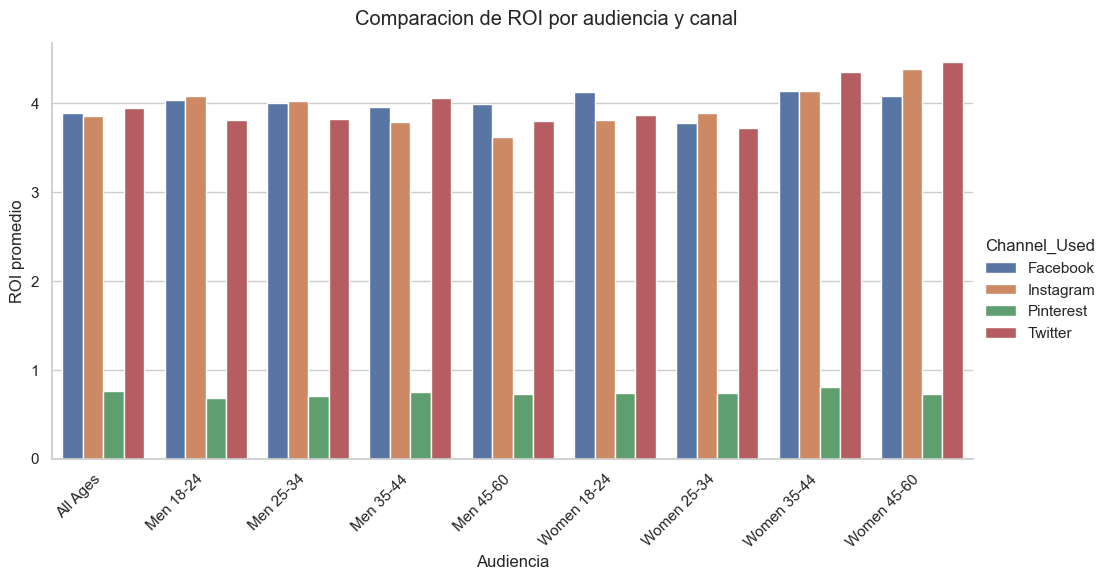

In [13]:
roi_por_audiencia_y_canal = (
    df.groupby(['Target_Audience', 'Channel_Used'], as_index=False)
    .agg(roi_promedio=('ROI', 'mean'))
)

g = sns.catplot(
    data=roi_por_audiencia_y_canal,
    kind='bar',
    x='Target_Audience',
    y='roi_promedio',
    hue='Channel_Used',
    height=5,
    aspect=2
)
g.fig.suptitle('Comparacion de ROI por audiencia y canal', y=1.03)
g.set_axis_labels('Audiencia', 'ROI promedio')
for ax in g.axes.flat:
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_horizontalalignment('right')
plt.show()


Pinterest es el peor canal dado a su poca concurrencia, sin embargo como su costo es barato puede tomarse en cuenta como un canal complementario

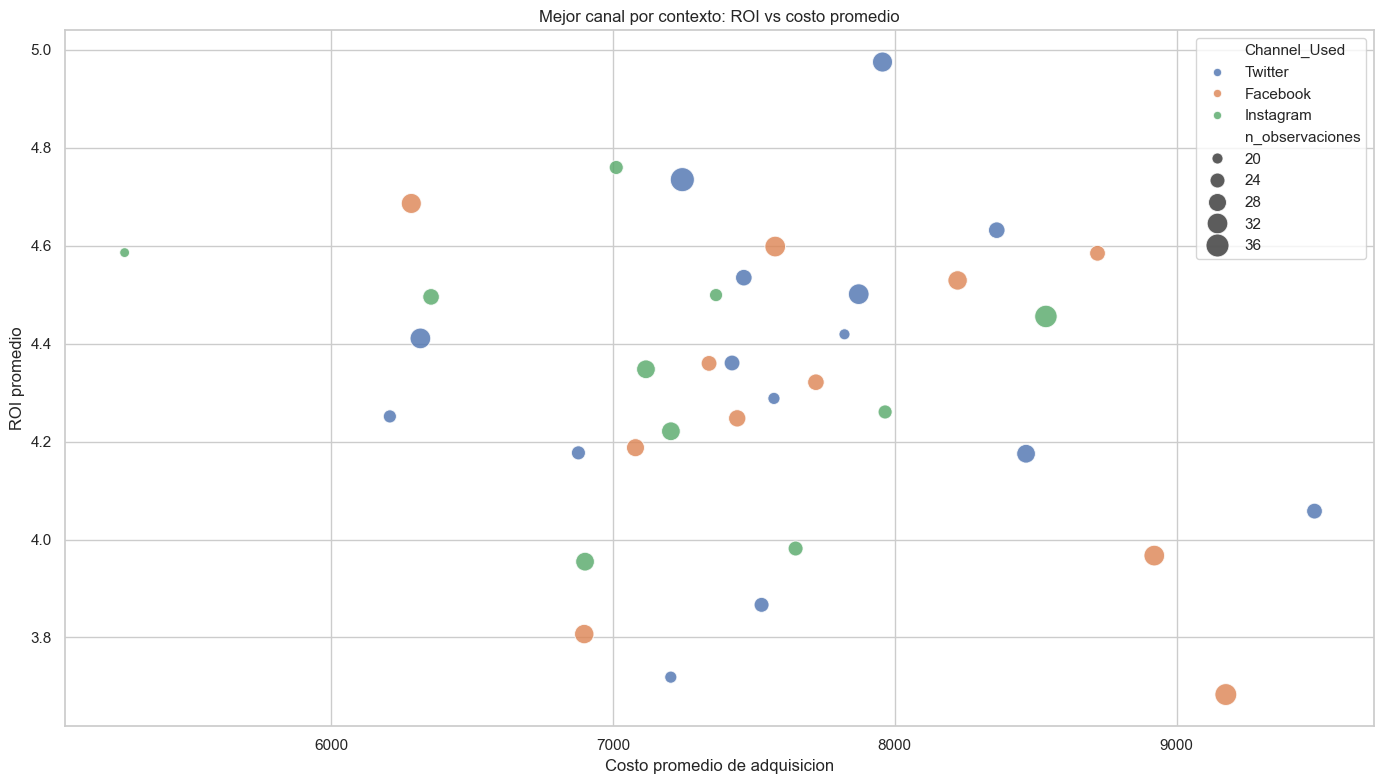

In [14]:
top_contextos = (
    tabla_agregada
    .sort_values(['Contexto', 'roi_promedio', 'conversion_promedio'], ascending=[True, False, False])
    .drop_duplicates('Contexto')
    .copy()
)

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=top_contextos,
    x='costo_promedio',
    y='roi_promedio',
    hue='Channel_Used',
    size='n_observaciones',
    sizes=(50, 300),
    alpha=0.8
)
plt.title('Mejor canal por contexto: ROI vs costo promedio')
plt.xlabel('Costo promedio de adquisicion')
plt.ylabel('ROI promedio')
plt.tight_layout()
plt.show()


Facebook tiene un montón de instancias en las que su costo promedio es mucho mayor al ROI que puede generar, mientras Twitter es el que reina en tener mejor balance entre estas métricas.

C:\Users\pedro\AppData\Local\Temp\ipykernel_1632\2429393001.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=resumen_canal_ganador, x='Channel_Used', y='cantidad_contextos_ganados', palette='viridis')


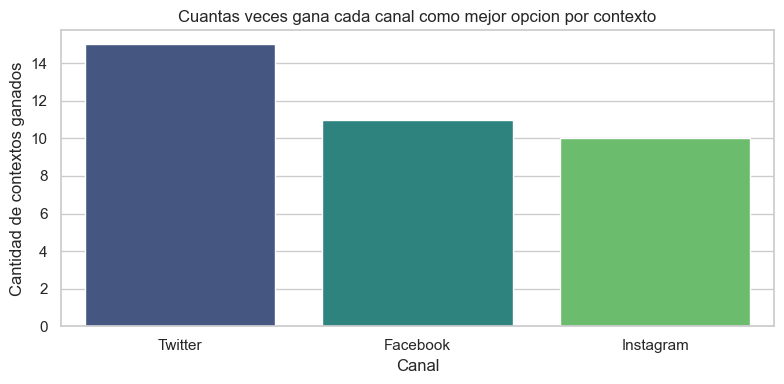

,Channel_Used,cantidad_contextos_ganados
2,Twitter,15
0,Facebook,11
1,Instagram,10


In [16]:
canal_ganador_contexto = (
    tabla_agregada
    .sort_values(['Contexto', 'roi_promedio', 'conversion_promedio'], ascending=[True, False, False])
    .drop_duplicates('Contexto')
)

resumen_canal_ganador = (
    canal_ganador_contexto.groupby('Channel_Used', as_index=False)
    .agg(cantidad_contextos_ganados=('Contexto', 'count'))
    .sort_values('cantidad_contextos_ganados', ascending=False)
)

plt.figure(figsize=(8, 4))
sns.barplot(data=resumen_canal_ganador, x='Channel_Used', y='cantidad_contextos_ganados', palette='viridis')
plt.title('Cuantas veces gana cada canal como mejor opcion por contexto')
plt.xlabel('Canal')
plt.ylabel('Cantidad de contextos ganados')
plt.tight_layout()
plt.show()

resumen_canal_ganador


## Conclusiones del análisis

- En general si se ve que no hay un canal que gane siempre en todo, sino que cambia bastante segun la combinacion de `Target_Audience` y `Campaign_Goal`.
- Facebook e Instagram parecen competir fuerte en varios contextos, pero Pinterest y Twitter tambien tienen casos donde sobresalen, entonces no conviene asumir un solo canal global para todos.
- El ROI tiene bastante variabilidad. Hay contextos donde el promedio es bueno pero tambien con dispersion alta, asi que seria riesgoso tomar decisiones solo con una vista agregada.
- El costo de adquisicion tambien cambia bastante entre canales y combinaciones, por eso no basta mirar solo conversion o solo clicks.
- Lo mas importante del EDA es que si hay señal para trabajar por contexto. O sea, si tiene sentido modelar `audiencia + objetivo` y no hacer una recomendacion unica para todo el dataset.
- Tambien se ve que hay combinaciones con mas observaciones que otras, entonces en la parte del bandit va a ser importante considerar exploracion y no solo explotacion.
- Con esto, la siguiente etapa tiene bastante sentido: construir un baseline histórico por contexto y despues comparar contra un enfoque de Thompson Sampling para aprender que canal recomendar en cada caso.

En resumen, este analisis sí respalda la idea del proyecto. Hay diferencias reales entre canales dependiendo del tipo de audiencia y del objetivo de campaña, asi que un sistema de recomendacion contextual parece una buena decision
